1.   Name: Maria John Abdou Hanna
2.   ID: 221001546



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, classification_report
import joblib

In [2]:
# CRITERIA: Raw, uncleaned dataset with real-world problems
df = pd.read_csv('/content/cardio_train.csv', sep=';')
print(f"Initial Dataset Shape: {df.shape}")
print(df.head())
print("\nNull values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Initial Dataset Shape: (70000, 13)
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  

Null values:
 id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Data types:
 id               int64
age              int64
gender           in

In [3]:
def clean_data(data):
    """
    Cleans the dataset:
    - Removes duplicate rows
    - Handles null/missing values
    - Removes impossible blood pressure values (outliers)
    """
    cleaned_df = data.copy()

    # 1. Remove duplicates
    initial_rows = cleaned_df.shape[0]
    cleaned_df.drop_duplicates(inplace=True)
    print(f"Removed {initial_rows - cleaned_df.shape[0]} duplicate rows.")

    # 2. Handle null values
    for col in cleaned_df.columns:
        null_count = cleaned_df[col].isnull().sum()
        if null_count > 0:
            if cleaned_df[col].dtype in ['int64', 'float64']:
                cleaned_df[col].fillna(cleaned_df[col].median(), inplace=True)
            else:
                cleaned_df[col].fillna(cleaned_df[col].mode()[0], inplace=True)
            print(f"Filled {null_count} null values in column: '{col}'")

    # 3. Remove medically impossible blood pressure values
    before = cleaned_df.shape[0]
    cleaned_df = cleaned_df[
        (cleaned_df['ap_hi'] >= 60) & (cleaned_df['ap_hi'] <= 250) &
        (cleaned_df['ap_lo'] >= 40) & (cleaned_df['ap_lo'] <= 200) &
        (cleaned_df['ap_hi'] > cleaned_df['ap_lo'])
    ]
    print(f"Removed {before - cleaned_df.shape[0]} rows with impossible blood pressure values.")

    print(f"\nFinal clean dataset shape: {cleaned_df.shape}")
    return cleaned_df

df_clean = clean_data(df)

Removed 0 duplicate rows.
Removed 1328 rows with impossible blood pressure values.

Final clean dataset shape: (68672, 13)


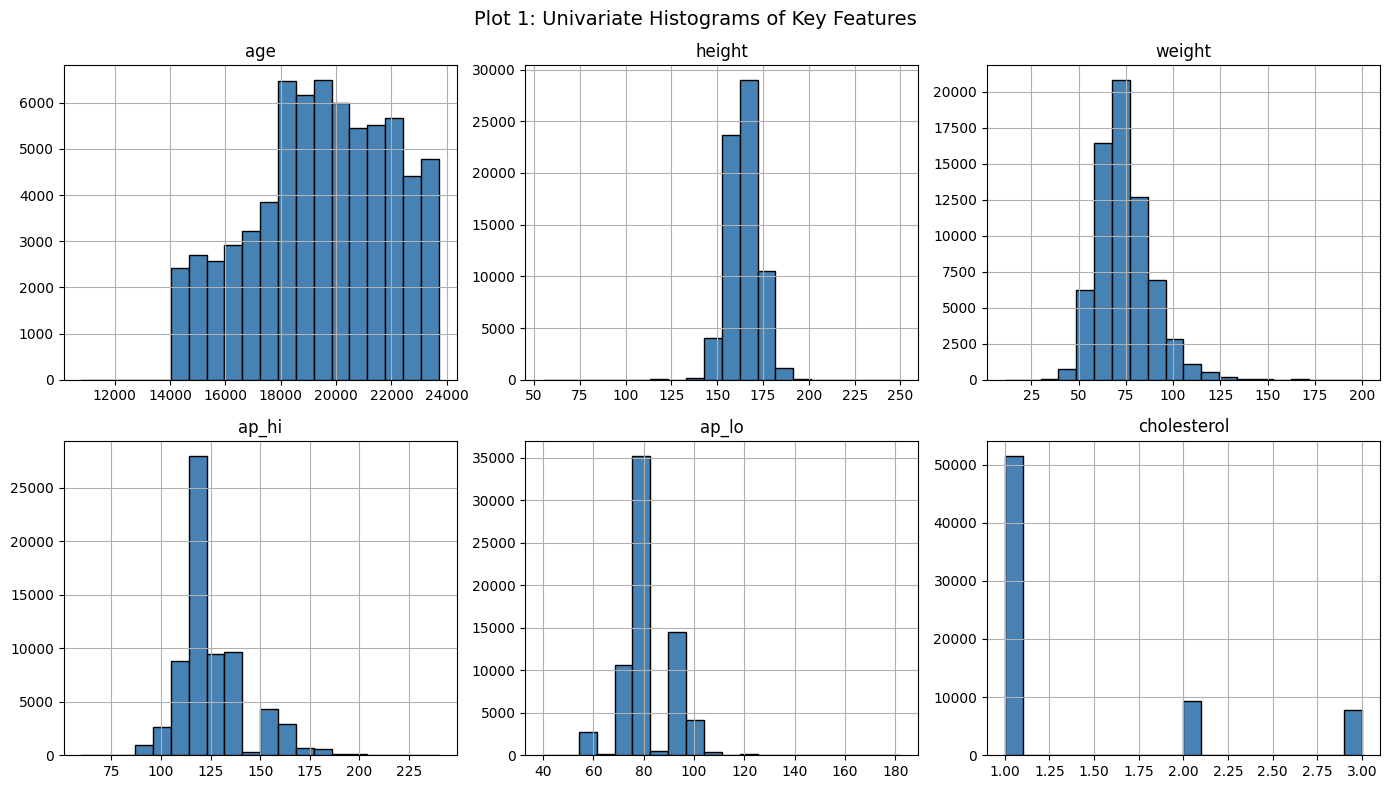

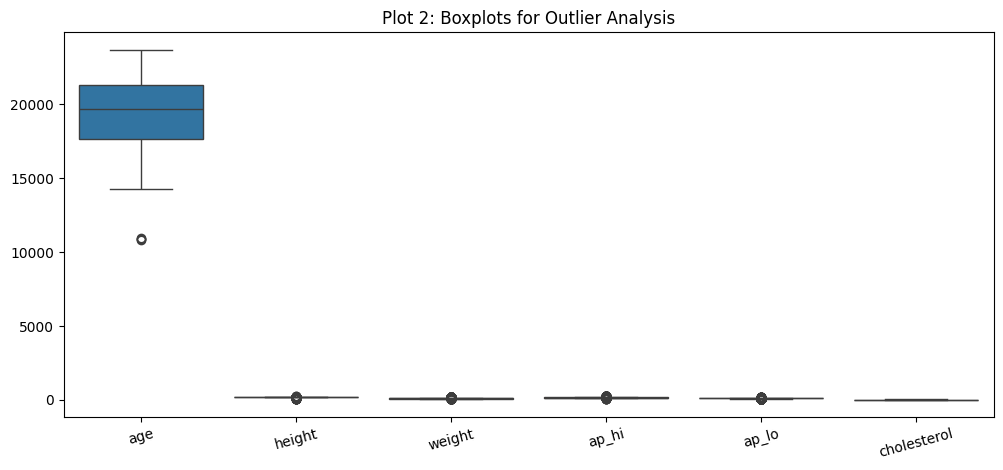

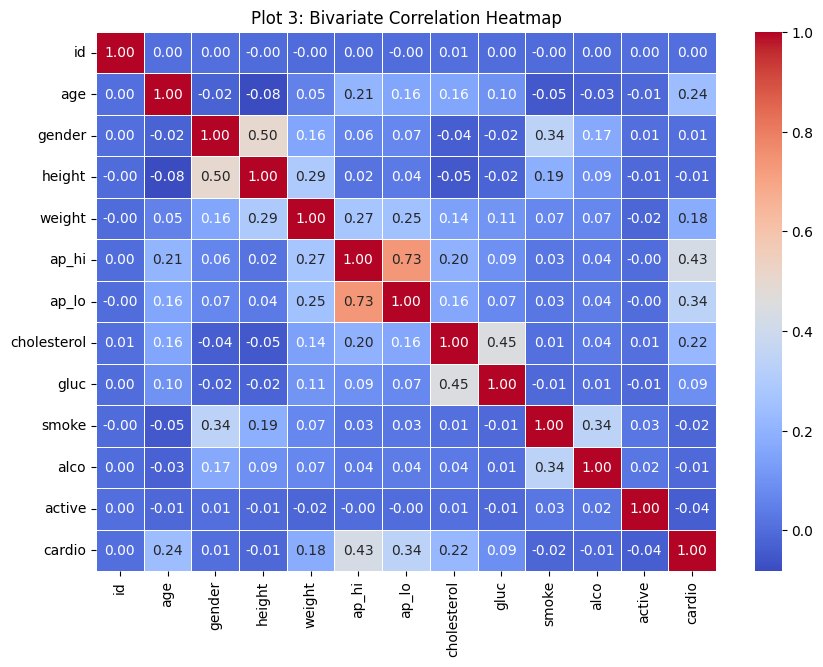

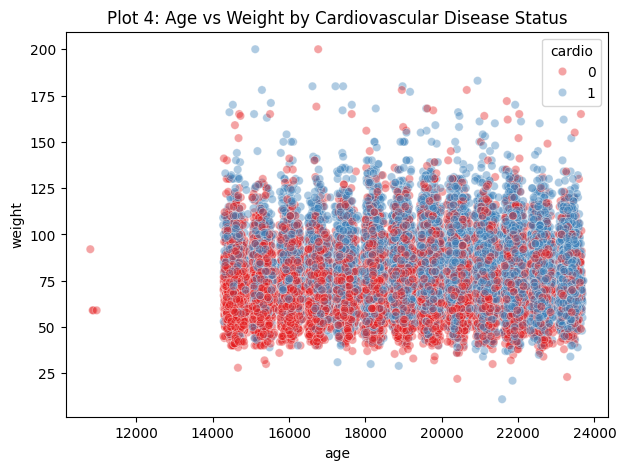

/tmp/ipykernel_2748/4206776222.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cardio', data=df_clean, palette='Set2')


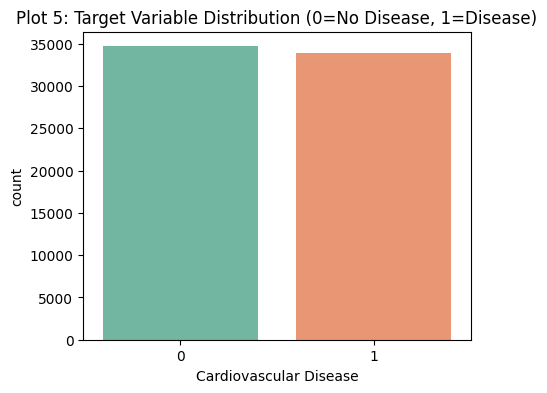

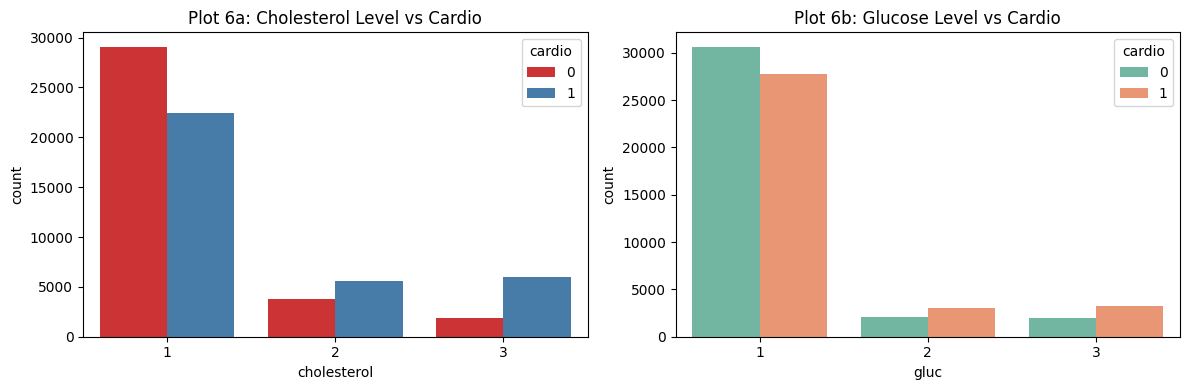

In [4]:
# Plot 1: Histograms — Univariate analysis of 6 key variables
features_to_plot = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi'] if 'bmi' in df_clean.columns else ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol']):
    df_clean[col].hist(bins=20, ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(col)
plt.suptitle("Plot 1: Univariate Histograms of Key Features", fontsize=14)
plt.tight_layout()
plt.show()

# Plot 2: Boxplots — Outlier detection
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_clean[['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol']])
plt.title("Plot 2: Boxplots for Outlier Analysis")
plt.xticks(rotation=15)
plt.show()

# Plot 3: Correlation Heatmap — Bivariate relationships
plt.figure(figsize=(10, 7))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Plot 3: Bivariate Correlation Heatmap")
plt.show()

# Plot 4: Scatter Plot — Age vs Weight, colored by cardiovascular disease
plt.figure(figsize=(7, 5))
sns.scatterplot(x='age', y='weight', hue='cardio', data=df_clean, alpha=0.4, palette='Set1')
plt.title("Plot 4: Age vs Weight by Cardiovascular Disease Status")
plt.show()

# Plot 5: Count Plot — Target class distribution
plt.figure(figsize=(5, 4))
sns.countplot(x='cardio', data=df_clean, palette='Set2')
plt.title("Plot 5: Target Variable Distribution (0=No Disease, 1=Disease)")
plt.xlabel("Cardiovascular Disease")
plt.show()

# Bonus Plot 6: Cholesterol & Glucose levels vs target (bivariate categorical)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='cholesterol', hue='cardio', data=df_clean, ax=axes[0], palette='Set1')
axes[0].set_title("Plot 6a: Cholesterol Level vs Cardio")
sns.countplot(x='gluc', hue='cardio', data=df_clean, ax=axes[1], palette='Set2')
axes[1].set_title("Plot 6b: Glucose Level vs Cardio")
plt.tight_layout()
plt.show()

In [5]:
# =====================================================================
# FEATURE ENGINEERING — Must match app.py exactly
# =====================================================================

# Drop the 'id' column — not a real feature
df_clean.drop(columns=['id'], inplace=True, errors='ignore')

# --- NEW FEATURE 1: BMI (Body Mass Index) ---
df_clean['bmi'] = df_clean['weight'] / ((df_clean['height'] / 100) ** 2)
print("Engineered feature: 'bmi'")

# --- NEW FEATURE 2: Pulse Pressure (Systolic - Diastolic) ---
df_clean['pulse_pressure'] = df_clean['ap_hi'] - df_clean['ap_lo']
print("Engineered feature: 'pulse_pressure'")

# --- Define X and y ---
# The 13 features below match EXACTLY what app.py sends to the model
FEATURE_COLUMNS = [
    'age', 'gender', 'height', 'weight',
    'ap_hi', 'ap_lo', 'cholesterol', 'gluc',
    'smoke', 'alco', 'active',
    'bmi', 'pulse_pressure'
]

X = df_clean[FEATURE_COLUMNS]
y = df_clean['cardio']

print(f"\nFinal feature set ({len(FEATURE_COLUMNS)} features): {FEATURE_COLUMNS}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Engineered feature: 'bmi'
Engineered feature: 'pulse_pressure'

Final feature set (13 features): ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'pulse_pressure']
X shape: (68672, 13), y shape: (68672,)


In [6]:
# CRITERIA: Feature Selection using Filter Method (ANOVA F-score)
# We show scores for transparency but keep ALL 13 features
# because the app.py is built around these exact 13 features
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

feature_scores = pd.DataFrame({
    'Feature': FEATURE_COLUMNS,
    'F-Score': selector.scores_,
    'P-Value': selector.pvalues_
}).sort_values('F-Score', ascending=False)

print("Feature Importance Scores (Filter Method - ANOVA F-test):")
print(feature_scores.to_string(index=False))

Feature Importance Scores (Filter Method - ANOVA F-test):
       Feature      F-Score       P-Value
         ap_hi 15399.843996  0.000000e+00
         ap_lo  8984.480476  0.000000e+00
pulse_pressure  8787.226583  0.000000e+00
           age  4174.892523  0.000000e+00
   cholesterol  3540.662920  0.000000e+00
        weight  2293.458854  0.000000e+00
           bmi  1907.596676  0.000000e+00
          gluc   555.782496 2.135964e-122
        active    96.188843  1.080812e-22
         smoke    18.260812  1.928886e-05
        height     7.920901  4.888083e-03
          alco     5.275851  2.162621e-02
        gender     3.455033  6.306374e-02


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features — this scaler gets saved and used in app.py
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set:     {X_test_scaled.shape}")

Training set: (54937, 13)
Test set:     (13735, 13)


In [8]:
# --- Model 1: Logistic Regression ---
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

# --- Model 2: Support Vector Machine ---
svc = SVC(probability=True)
svc.fit(X_train_scaled, y_train)

# --- Model 3: Random Forest with GridSearchCV Tuning ---
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='accuracy', verbose=1)
grid_search.fit(X_train_scaled, y_train)

best_rf = grid_search.best_estimator_
print(f"\nBest Random Forest parameters: {grid_search.best_params_}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best Random Forest parameters: {'max_depth': 10, 'n_estimators': 100}


In [9]:
# CRITERIA: At least 2 metrics (precision & recall), all must be >= 0.3
models = {
    'Logistic Regression': lr,
    'SVC': svc,
    'Tuned Random Forest': best_rf
}

for name, model in models.items():
    preds = model.predict(X_test_scaled)
    precision = precision_score(y_test, preds, average='macro')
    recall = recall_score(y_test, preds, average='macro')
    print(f"\n--- {name} ---")
    print(f"Precision: {precision:.4f}  (must be >= 0.3 ✅)" if precision >= 0.3 else f"Precision: {precision:.4f}  ❌ BELOW 0.3")
    print(f"Recall:    {recall:.4f}  (must be >= 0.3 ✅)" if recall >= 0.3 else f"Recall: {recall:.4f}  ❌ BELOW 0.3")
    print(classification_report(y_test, preds))


--- Logistic Regression ---
Precision: 0.7281  (must be >= 0.3 ✅)
Recall:    0.7240  (must be >= 0.3 ✅)
              precision    recall  f1-score   support

           0       0.70      0.79      0.74      6908
           1       0.76      0.66      0.70      6827

    accuracy                           0.72     13735
   macro avg       0.73      0.72      0.72     13735
weighted avg       0.73      0.72      0.72     13735


--- SVC ---
Precision: 0.7338  (must be >= 0.3 ✅)
Recall:    0.7289  (must be >= 0.3 ✅)
              precision    recall  f1-score   support

           0       0.70      0.80      0.75      6908
           1       0.76      0.66      0.71      6827

    accuracy                           0.73     13735
   macro avg       0.73      0.73      0.73     13735
weighted avg       0.73      0.73      0.73     13735


--- Tuned Random Forest ---
Precision: 0.7377  (must be >= 0.3 ✅)
Recall:    0.7318  (must be >= 0.3 ✅)
              precision    recall  f1-score   s

In [10]:
# Save the best model and scaler
joblib.dump(best_rf, 'saved_model.pkl')
joblib.dump(scaler, 'saved_transformer.pkl')
print("✅ saved_model.pkl saved")
print("✅ saved_transformer.pkl saved")

# Download them from Colab
from google.colab import files
files.download('saved_model.pkl')
files.download('saved_transformer.pkl')

✅ saved_model.pkl saved
✅ saved_transformer.pkl saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
import sys
!{sys.executable} -m pip install streamlit
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Set up page configurations for a clean layout
st.set_page_config(
    page_title="Cardiovascular Disease Predictor",
    page_icon="❤️",
    layout="centered"
)

# Load the saved model and transformer pipeline artifacts
# CRITERIA CHECK: Uses the saved transformers and saved model components
@st.cache_resource
def load_artifacts():
    try:
        model = joblib.load('saved_model.pkl')
        scaler = joblib.load('saved_transformer.pkl')
        return model, scaler
    except FileNotFoundError:
        st.error("⚠️ Error: 'saved_model.pkl' or 'saved_transformer.pkl' not found. Ensure they are in the same directory as this app.")
        return None, None

model, scaler = load_artifacts()

# Title and Description
st.title("❤️ Cardiovascular Disease Risk Predictor")
st.write("""
This machine learning application predicts the likelihood of cardiovascular disease based on patient clinical and physiological parameters.
""")
st.markdown("---")

# Organized User Input Form
st.header("Patient Medical Profile")
st.write("Please enter the patient's medical details below:")

col1, col2 = st.columns(2)

with col1:
    # Age input in years, converted to days inside the script to match the raw dataset feature format
    age_years = st.number_input("Age (in Years)", min_value=1, max_value=120, value=50, step=1)
    age_days = age_years * 365.25

    gender = st.selectbox("Gender", options=["Female", "Male"], index=0)
    gender_encoded = 1 if gender == "Female" else 2

    height = st.number_input("Height (cm)", min_value=50, max_value=250, value=165, step=1)
    weight = st.number_input("Weight (kg)", min_value=10.0, max_value=300.0, value=70.0, step=0.1)

with col2:
    ap_hi = st.number_input("Systolic Blood Pressure (ap_hi)", min_value=40, max_value=300, value=120, step=1)
    ap_lo = st.number_input("Diastolic Blood Pressure (ap_lo)", min_value=30, max_value=200, value=80, step=1)

    cholesterol = st.selectbox("Cholesterol Level", options=["1: Normal", "2: Above Normal", "3: Well Above Normal"], index=0)
    chol_encoded = int(cholesterol.split(":")[0])

    gluc = st.selectbox("Glucose Level", options=["1: Normal", "2: Above Normal", "3: Well Above Normal"], index=0)
    gluc_encoded = int(gluc.split(":")[0])

st.markdown("### Lifestyle Factors")
col3, col4, col5 = st.columns(3)

with col3:
    smoke = st.checkbox("Smoking History")
    smoke_encoded = 1 if smoke else 0

with col4:
    alco = st.checkbox("Alcohol Consumption")
    alco_encoded = 1 if alco else 0

with col5:
    active = st.checkbox("Physically Active", value=True)
    active_encoded = 1 if active else 0

# --- FEATURE ENGINEERING ---
# CRITERIA CHECK: Re-implement the exact feature engineering pipeline used during training
# 1. Body Mass Index (BMI)
bmi = weight / ((height / 100) ** 2)

# 2. Pulse Pressure (Interaction feature between Systolic and Diastolic pressure)
pulse_pressure = ap_hi - ap_lo

st.markdown("---")

# Prediction Trigger
if st.button("Analyze Cardiovascular Risk", type="primary"):
    if model is not None and scaler is not None:

        # Structure raw inputs in the exact array format and column order expected by the pipeline
        raw_features = np.array([[
            age_days, gender_encoded, height, weight,
            ap_hi, ap_lo, chol_encoded, gluc_encoded,
            smoke_encoded, alco_encoded, active_encoded,
            bmi, pulse_pressure
        ]])

        # Transform features using the saved scaler artifact
        scaled_features = scaler.transform(raw_features)

        # Calculate final prediction and probability mappings
        prediction = model.predict(scaled_features)[0]
        probabilities = model.predict_proba(scaled_features)[0]
        risk_probability = probabilities[1] * 100

        # Display Visual Results to the user
        st.header("Analysis Results")

        if prediction == 1:
            st.error(f"🔴 **High Risk Detected:** The patient has a high probability of cardiovascular disease.")
        else:
            st.success(f"🟢 **Low Risk Detected:** The patient has a low probability of cardiovascular disease.")

        # Display progress bar showing probability scaling
        st.write(f"Calculated Risk Probability: **{risk_probability:.2f}%**")
        st.progress(int(risk_probability))

    else:
        st.error("Could not run prediction because model artifacts are missing.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 96.3 MB/s eta 0:00:00


2026-05-28 16:52:51.166 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 16:52:51.168 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 16:52:51.209 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 16:52:51.407 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-28 16:52:51.407 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 16:52:51.409 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 16:52:51.410 Thread 'MainThread'

In [13]:
%%writefile app.py
import sys
!{sys.executable} -m pip install streamlit
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Set up page configurations for a clean layout
st.set_page_config(
    page_title="Cardiovascular Disease Predictor",
    page_icon="❤️",
    layout="centered"
)

# Load the saved model and transformer pipeline artifacts
# CRITERIA CHECK: Uses the saved transformers and saved model components
@st.cache_resource
def load_artifacts():
    try:
        model = joblib.load('saved_model.pkl')
        scaler = joblib.load('saved_transformer.pkl')
        return model, scaler
    except FileNotFoundError:
        st.error("⚠️ Error: 'saved_model.pkl' or 'saved_transformer.pkl' not found. Ensure they are in the same directory as this app.")
        return None, None

model, scaler = load_artifacts()

# Title and Description
st.title("❤️ Cardiovascular Disease Risk Predictor")
st.write("""
This machine learning application predicts the likelihood of cardiovascular disease based on patient clinical and physiological parameters.
""")
st.markdown("---")

# Organized User Input Form
st.header("Patient Medical Profile")
st.write("Please enter the patient's medical details below:")

col1, col2 = st.columns(2)

with col1:
    # Age input in years, converted to days inside the script to match the raw dataset feature format
    age_years = st.number_input("Age (in Years)", min_value=1, max_value=120, value=50, step=1)
    age_days = age_years * 365.25

    gender = st.selectbox("Gender", options=["Female", "Male"], index=0)
    gender_encoded = 1 if gender == "Female" else 2

    height = st.number_input("Height (cm)", min_value=50, max_value=250, value=165, step=1)
    weight = st.number_input("Weight (kg)", min_value=10.0, max_value=300.0, value=70.0, step=0.1)

with col2:
    ap_hi = st.number_input("Systolic Blood Pressure (ap_hi)", min_value=40, max_value=300, value=120, step=1)
    ap_lo = st.number_input("Diastolic Blood Pressure (ap_lo)", min_value=30, max_value=200, value=80, step=1)

    cholesterol = st.selectbox("Cholesterol Level", options=["1: Normal", "2: Above Normal", "3: Well Above Normal"], index=0)
    chol_encoded = int(cholesterol.split(":")[0])

    gluc = st.selectbox("Glucose Level", options=["1: Normal", "2: Above Normal", "3: Well Above Normal"], index=0)
    gluc_encoded = int(gluc.split(":")[0])

st.markdown("### Lifestyle Factors")
col3, col4, col5 = st.columns(3)

with col3:
    smoke = st.checkbox("Smoking History")
    smoke_encoded = 1 if smoke else 0

with col4:
    alco = st.checkbox("Alcohol Consumption")
    alco_encoded = 1 if alco else 0

with col5:
    active = st.checkbox("Physically Active", value=True)
    active_encoded = 1 if active else 0

# --- FEATURE ENGINEERING ---
# CRITERIA CHECK: Re-implement the exact feature engineering pipeline used during training
# 1. Body Mass Index (BMI)
bmi = weight / ((height / 100) ** 2)

# 2. Pulse Pressure (Interaction feature between Systolic and Diastolic pressure)
pulse_pressure = ap_hi - ap_lo

st.markdown("---")

# Prediction Trigger
if st.button("Analyze Cardiovascular Risk", type="primary"):
    if model is not None and scaler is not None:

        # Structure raw inputs in the exact array format and column order expected by the pipeline
        raw_features = np.array([[
            age_days, gender_encoded, height, weight,
            ap_hi, ap_lo, chol_encoded, gluc_encoded,
            smoke_encoded, alco_encoded, active_encoded,
            bmi, pulse_pressure
        ]])

        # Transform features using the saved scaler artifact
        scaled_features = scaler.transform(raw_features)

        # Calculate final prediction and probability mappings
        prediction = model.predict(scaled_features)[0]
        probabilities = model.predict_proba(scaled_features)[0]
        risk_probability = probabilities[1] * 100

        # Display Visual Results to the user
        st.header("Analysis Results")

        if prediction == 1:
            st.error(f"🔴 **High Risk Detected:** The patient has a high probability of cardiovascular disease.")
        else:
            st.success(f"🟢 **Low Risk Detected:** The patient has a low probability of cardiovascular disease.")

        # Display progress bar showing probability scaling
        st.write(f"Calculated Risk Probability: **{risk_probability:.2f}%**")
        st.progress(int(risk_probability))

    else:
        st.error("Could not run prediction because model artifacts are missing.")

Writing app.py


In [14]:
from google.colab import files
files.download('app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>